# Exploración y hallazgos — GH-AW Workflows Dataset

Este notebook explora las variables del dataset descrito y revisado en
[`01_descripcion_y_calidad.ipynb`](01_descripcion_y_calidad.ipynb), busca
patrones, y presenta los hallazgos principales.

**Dataset publicado en Hugging Face:**
[EstebanCQ/gh-aw-workflows-dataset](https://huggingface.co/datasets/EstebanCQ/gh-aw-workflows-dataset)


## 1. Carga de los datos para el análisis

Se cargan las tablas **preparadas** en el Notebook 1 (`data/processed/`),
no las originales (`data/raw/`) -- así este notebook no depende de
variables que hayan quedado en memoria de la ejecución anterior, y
refleja el tratamiento aplicado (columna `has_frontmatter` agregada a
`workflow_files`).

Tablas y unidad de análisis en cada una:

| Tabla | Unidad analizada |
|---|---|
| `repositories` | Un repositorio de GitHub. |
| `workflow_files` | Un archivo `.md` de workflow GH-AW. |
| `frontmatter_attributes` | Un atributo individual de frontmatter (no es una entidad por sí sola; se usa siempre relacionada con `workflow_files` vía `file_id`). |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA_DIR = Path("data/processed")

repositories = pd.read_parquet(DATA_DIR / "repositories.parquet")
workflow_files = pd.read_parquet(DATA_DIR / "workflow_files.parquet")
frontmatter_attributes = pd.read_parquet(DATA_DIR / "frontmatter_attributes.parquet")

print(f"repositories:           {repositories.shape[0]} filas")
print(f"workflow_files:         {workflow_files.shape[0]} filas")
print(f"frontmatter_attributes: {frontmatter_attributes.shape[0]} filas")

repositories:           345 filas
workflow_files:         1409 filas
frontmatter_attributes: 58573 filas


## 2. Distribución de archivos por repositorio

Se calcula, para cada repositorio, cuántos archivos `.md` de workflow
GH-AW tiene, y se describe la forma de esa distribución.


In [2]:
archivos_por_repo = (
    workflow_files.groupby("repo_id").size().rename("n_archivos").reset_index()
)

resumen_archivos_por_repo = archivos_por_repo["n_archivos"].agg(["min", "max", "mean", "median"]).to_frame("valor")
resumen_archivos_por_repo

,valor
min,1.000000
max,299.000000
mean,4.084058
median,1.000000


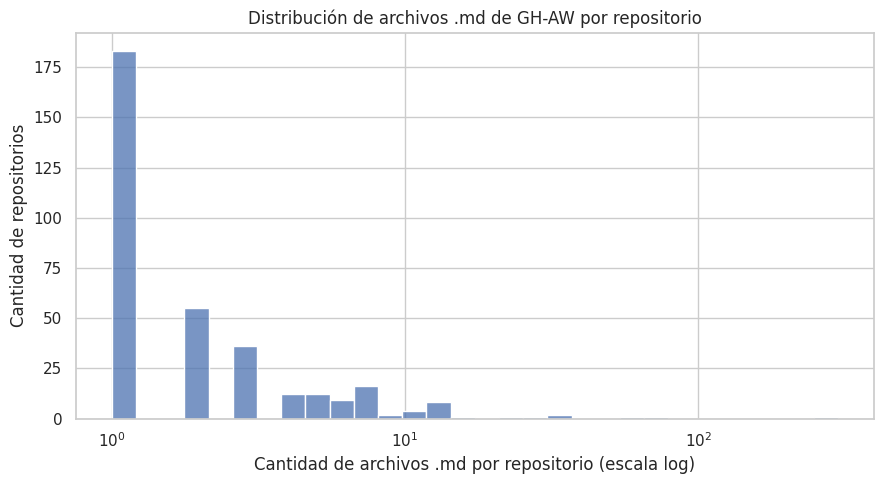

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(archivos_por_repo["n_archivos"], bins=30, log_scale=(True, False), ax=ax)
ax.set_title("Distribución de archivos .md de GH-AW por repositorio")
ax.set_xlabel("Cantidad de archivos .md por repositorio (escala log)")
ax.set_ylabel("Cantidad de repositorios")
plt.tight_layout()
plt.show()

In [4]:
n_un_solo_archivo = (archivos_por_repo["n_archivos"] == 1).sum()
pct_un_solo_archivo = n_un_solo_archivo / len(archivos_por_repo) * 100

top_repos = (
    archivos_por_repo.sort_values("n_archivos", ascending=False)
    .head(5)
    .merge(repositories[["repo_id", "full_name"]], on="repo_id")
    [["full_name", "n_archivos"]]
)
print(f"Repositorios con exactamente 1 archivo: {n_un_solo_archivo} de {len(archivos_por_repo)} ({pct_un_solo_archivo:.1f}%)")
print()
print("Top 5 repositorios con más archivos de workflow:")
top_repos

Repositorios con exactamente 1 archivo: 183 de 345 (53.0%)

Top 5 repositorios con más archivos de workflow:


,full_name,n_archivos
0,github/gh-aw,299
1,github/gh-aw-firewall,70
2,elastic/ai-github-actions,57
3,github/gh-aw-mcpg,36
4,microsoft/testfx,35


**Interpretación:** la distribución es fuertemente asimétrica hacia la
derecha (*right-skewed*): la mediana es 1 archivo por repositorio pero la
media es 4.1, arrastrada por unos pocos repositorios con decenas o
cientos de workflows. Más de la mitad de los repositorios (183 de 345,
~53%) tienen exactamente **un solo** archivo de workflow GH-AW -- el
patrón típico de un equipo que adopta la herramienta para un caso de uso
puntual (por ejemplo, un reporte diario automatizado).

En el extremo opuesto, el repositorio con más archivos es
**`github/gh-aw`** (299 workflows), seguido de `github/gh-aw-firewall`
(70) y `github/gh-aw-mcpg` (36) -- los tres son repositorios del propio
equipo que desarrolla GH-AW, que acumulan una gran cantidad de ejemplos y
plantillas de referencia, no proyectos "de uso normal" de la herramienta.
Esto es importante para el resto del análisis: cualquier estadística a
nivel de *archivo* (en vez de a nivel de *repositorio*) va a estar
sobre-representada por estos pocos repositorios de referencia.


## 3. Exploración del frontmatter

### 3.1 Cobertura general de campos

`frontmatter_attributes` es una tabla larga: cada fila es un atributo, no
un archivo. Para saber qué tan frecuente es cada campo, se cuenta cuántos
**archivos distintos** (no filas) declaran cada campo de primer nivel del
frontmatter (por ejemplo, `permissions.contents` y `permissions.issues`
cuentan ambos para el campo `permissions`).


In [5]:
import re

def top_level_field(key_path: str) -> str:
    return re.match(r"^([^.\[]+)", key_path).group(1)

frontmatter_attributes = frontmatter_attributes.copy()
frontmatter_attributes["campo"] = frontmatter_attributes["key_path"].apply(top_level_field)

n_files = workflow_files["file_id"].nunique()
cobertura = (
    frontmatter_attributes.groupby("campo")["file_id"].nunique()
    .sort_values(ascending=False)
    .rename("n_archivos")
    .to_frame()
)
cobertura["pct_archivos"] = (cobertura["n_archivos"] / n_files * 100).round(1)
cobertura.head(15)

,n_archivos,pct_archivos
campo,,
on,1408,99.9
permissions,1392,98.8
safe-outputs,1324,94.0
tools,1281,90.9
description,1256,89.1
timeout-minutes,1041,73.9
network,965,68.5
engine,884,62.7
name,725,51.5


### 3.2 Atributo 1: motor de IA (`engine`)

Se declara de dos formas distintas en el frontmatter de gh-aw: como texto
simple (`engine: claude`, `key_path == "engine"`) o como objeto con un
subcampo `id` (`engine: {id: claude, model: ...}`,
`key_path == "engine.id"`). **Cómo se cuenta:** se combinan (coalesce)
ambas formas en un solo valor por archivo -- se verificó que ningún
archivo usa las dos formas a la vez, así que no hay ambigüedad al
combinarlas. Cada archivo aporta como máximo un motor a la tabla de
frecuencias.


In [6]:
engine_simple = frontmatter_attributes[frontmatter_attributes["key_path"] == "engine"][["file_id", "value"]]
engine_anidado = frontmatter_attributes[frontmatter_attributes["key_path"] == "engine.id"][["file_id", "value"]]
engine_por_archivo = pd.concat([engine_simple, engine_anidado]).drop_duplicates("file_id")

n_con_engine = len(engine_por_archivo)
print(f"Archivos con motor de IA declarado: {n_con_engine} de {n_files} ({n_con_engine/n_files*100:.1f}%)")

frecuencia_engine = engine_por_archivo["value"].value_counts().rename("n_archivos").to_frame()
frecuencia_engine["pct_del_total"] = (frecuencia_engine["n_archivos"] / n_files * 100).round(1)
frecuencia_engine

Archivos con motor de IA declarado: 882 de 1409 (62.6%)


,n_archivos,pct_del_total
value,,
copilot,565,40.1
claude,155,11.0
codex,131,9.3
pi,11,0.8
gemini,4,0.3
opencode,4,0.3
aider,3,0.2
goose,3,0.2
pydantic-ai,2,0.1


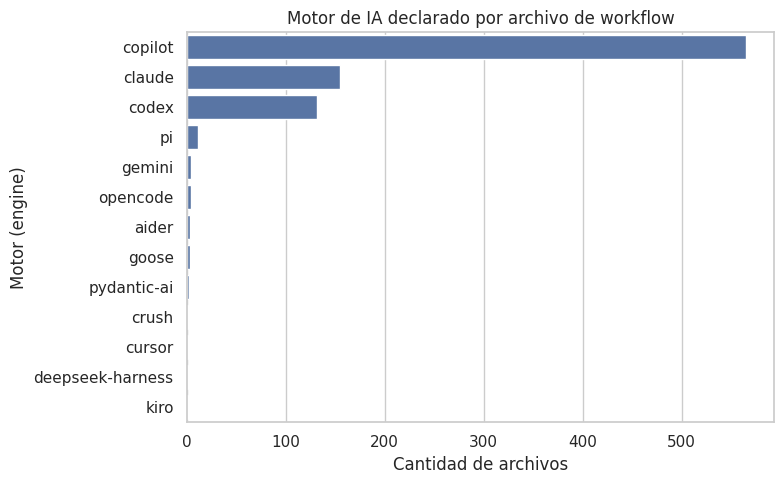

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
orden = frecuencia_engine.index
sns.barplot(x=frecuencia_engine["n_archivos"], y=orden, ax=ax, orient="h")
ax.set_title("Motor de IA declarado por archivo de workflow")
ax.set_xlabel("Cantidad de archivos")
ax.set_ylabel("Motor (engine)")
plt.tight_layout()
plt.show()

**Interpretación:** solo 882 de 1.409 archivos (~62.6%) declaran
explícitamente un motor de IA; el resto probablemente usa el valor por
defecto de gh-aw sin declararlo. Entre los que sí lo declaran,
**Copilot** domina claramente (390+175=565 archivos combinando ambas
formas), seguido de **Codex** y **Claude** en un rango similar, y una
cola larga de motores minoritarios (Gemini, Aider, Goose, Cursor, entre
otros) con muy pocos archivos cada uno -- coherente con Copilot siendo el
motor de IA más integrado nativamente al ecosistema de GitHub Actions.


### 3.3 Atributo 2: permiso sobre el contenido del repositorio (`permissions.contents`)


In [8]:
perm_contents = frontmatter_attributes[frontmatter_attributes["key_path"] == "permissions.contents"]
n_con_permiso = perm_contents["file_id"].nunique()
print(f"Archivos que declaran permissions.contents: {n_con_permiso} de {n_files} ({n_con_permiso/n_files*100:.1f}%)")

frecuencia_permiso = perm_contents["value"].value_counts().rename("n_archivos").to_frame()
frecuencia_permiso["pct_del_total"] = (frecuencia_permiso["n_archivos"] / n_files * 100).round(1)
frecuencia_permiso

Archivos que declaran permissions.contents: 1237 de 1409 (87.8%)


,n_archivos,pct_del_total
value,,
read,1235,87.7
write,2,0.1


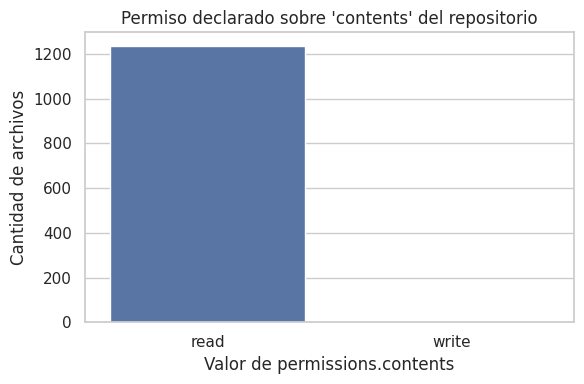

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=frecuencia_permiso.index, y=frecuencia_permiso["n_archivos"], ax=ax)
ax.set_title("Permiso declarado sobre 'contents' del repositorio")
ax.set_xlabel("Valor de permissions.contents")
ax.set_ylabel("Cantidad de archivos")
plt.tight_layout()
plt.show()

**Interpretación:** de los 1.237 archivos que declaran explícitamente
este permiso, la abrumadora mayoría (1.235, 99.8%) pide acceso de solo
**lectura** sobre el contenido del repositorio, y únicamente 2 piden
**escritura**. Esto es consistente con el principio de menor privilegio
que promueve gh-aw: los agentes de IA que ejecutan estos workflows
normalmente solo necesitan leer código/archivos para hacer su tarea (por
ejemplo, generar un resumen), y las acciones que sí modifican el
repositorio (crear PRs, comentarios) suelen pasar por permisos más
específicos como `pull-requests` o `issues`, no por `contents: write`.


### 3.4 Atributo 3: eventos de activación (`on.*`)

A diferencia de los dos atributos anteriores, un mismo workflow puede
declarar **varios** triggers a la vez (por ejemplo, `workflow_dispatch` +
`schedule`). **Cómo se cuenta:** cada archivo se cuenta una vez por cada
tipo de trigger que declara -- un archivo con 3 triggers aporta a 3
categorías distintas. Por eso los porcentajes de la tabla **no suman
100%**, cosa que sí ocurría en los dos atributos anteriores (de valor
único por archivo).


In [10]:
on_attrs = frontmatter_attributes[
    (frontmatter_attributes["key_path"] == "on") | (frontmatter_attributes["key_path"].str.startswith("on."))
].copy()

def trigger_type(key_path: str) -> str:
    if key_path == "on":
        return "(vacío / sin sub-triggers)"
    return re.match(r"^on\.([^.\[]+)", key_path).group(1)

on_attrs["trigger"] = on_attrs["key_path"].apply(trigger_type)

frecuencia_triggers = (
    on_attrs.groupby("trigger")["file_id"].nunique()
    .sort_values(ascending=False)
    .rename("n_archivos")
    .to_frame()
)
frecuencia_triggers["pct_del_total"] = (frecuencia_triggers["n_archivos"] / n_files * 100).round(1)
frecuencia_triggers.head(10)

,n_archivos,pct_del_total
trigger,,
workflow_dispatch,1002,71.1
schedule,740,52.5
roles,237,16.8
slash_command,184,13.1
reaction,181,12.8
issues,150,10.6
pull_request,145,10.3
permissions,105,7.5
steps,99,7.0


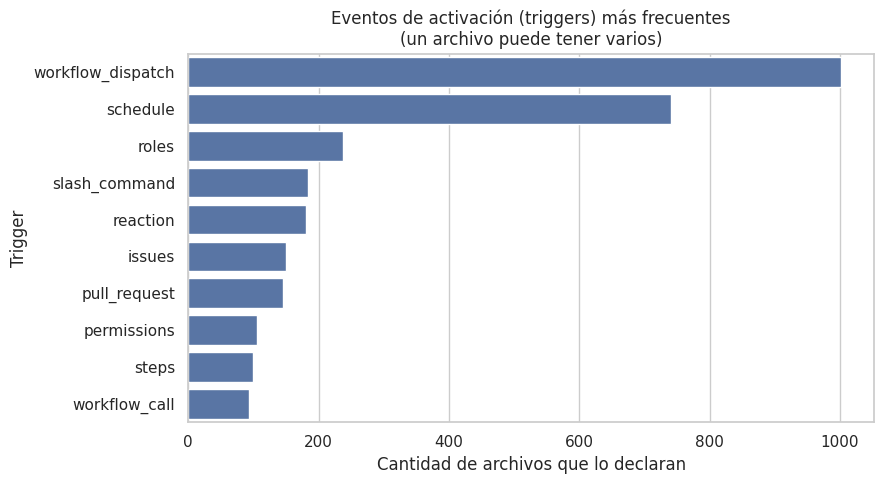

In [11]:
top10_triggers = frecuencia_triggers.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top10_triggers["n_archivos"], y=top10_triggers.index, ax=ax, orient="h")
ax.set_title("Eventos de activación (triggers) más frecuentes\n(un archivo puede tener varios)")
ax.set_xlabel("Cantidad de archivos que lo declaran")
ax.set_ylabel("Trigger")
plt.tight_layout()
plt.show()

**Interpretación:** `workflow_dispatch` (activación manual, 1.002
archivos, 71.1%) y `schedule` (activación programada tipo cron, 740
archivos, 52.5%) dominan claramente sobre los triggers reactivos a
eventos de GitHub como `issues` o `pull_request`. Esto sugiere que la
mayoría de los workflows de GH-AW están pensados para ejecutarse *bajo
demanda* o en un *horario fijo* (por ejemplo, un resumen diario), más que
para reaccionar automáticamente a cada issue o PR nuevo -- un patrón
consistente con agentes de IA que hacen tareas de mantenimiento
periódicas en vez de bots que responden a cada evento del repositorio.


## 4. Exploración del body

Se calcula la longitud en palabras del `body_markdown` de cada archivo
(las instrucciones en lenguaje natural para el agente de IA).


In [12]:
workflow_files["n_palabras_body"] = workflow_files["body_markdown"].str.split().str.len()

resumen_body = workflow_files["n_palabras_body"].agg(["min", "max", "mean", "median"]).round(1).to_frame("palabras")
n_body_vacio = (workflow_files["n_palabras_body"] == 0).sum()
print(f"Archivos con body vacío (0 palabras): {n_body_vacio} de {len(workflow_files)}")
resumen_body

Archivos con body vacío (0 palabras): 0 de 1409


,palabras
min,3.0
max,15217.0
mean,1020.6
median,712.0


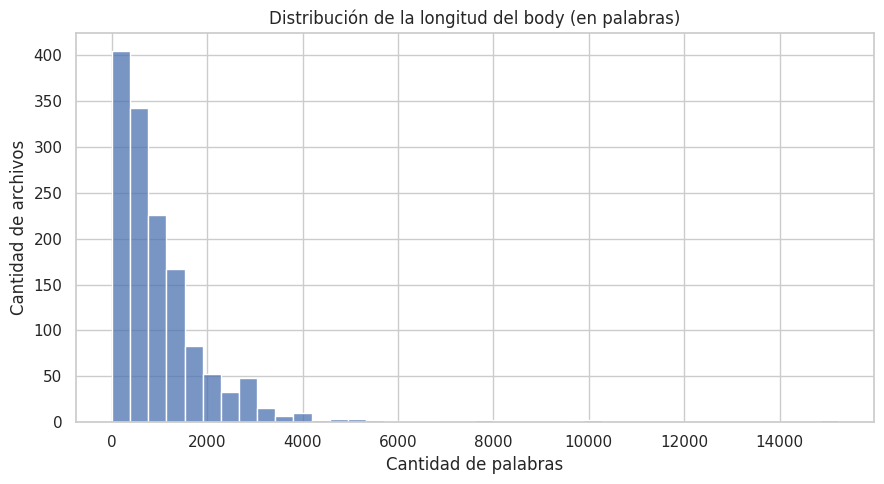

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(workflow_files["n_palabras_body"], bins=40, ax=ax)
ax.set_title("Distribución de la longitud del body (en palabras)")
ax.set_xlabel("Cantidad de palabras")
ax.set_ylabel("Cantidad de archivos")
plt.tight_layout()
plt.show()

In [14]:
cols = ["file_id", "repo_id", "file_name", "file_path", "n_palabras_body"]
con_repo = workflow_files[cols].merge(repositories[["repo_id", "full_name"]], on="repo_id")

print("Top 5 archivos con body más largo:")
display(con_repo.nlargest(5, "n_palabras_body")[["full_name", "file_path", "n_palabras_body"]])

print()
print("Top 5 archivos con body más corto:")
display(con_repo.nsmallest(5, "n_palabras_body")[["full_name", "file_path", "n_palabras_body"]])

Top 5 archivos con body más largo:


,full_name,file_path,n_palabras_body
98,dotnet/maui,.github/workflows/ci-status-fix-net11.md,15217
74,dotnet/maui,.github/workflows/ci-status-fix.md,15175
807,Azure/terraform-azurerm-avm-res-resources-reso...,.github/workflows/issue-triage.md,10191
107,dotnet/aspnetcore,.github/workflows/test-quarantine.md,10170
485,tenstorrent/tt-metal,.github/workflows/silencer.md,9549



Top 5 archivos con body más corto:


,full_name,file_path,n_palabras_body
509,pydantic/pydantic-ai,.github/workflows/pydantic-ai-bug-hunter.md,3
531,pydantic/pydantic-ai,.github/workflows/pydantic-ai-docs-drift.md,3
579,pydantic/pydantic-ai,.github/workflows/pydantic-ai-provider-mapping...,3
592,pydantic/pydantic-ai,.github/workflows/pydantic-ai-provider-parity-...,3
607,pydantic/pydantic-ai,.github/workflows/pydantic-ai-regression-detec...,3


**Interpretación:** ningún archivo tiene el body vacío. La distribución
está sesgada a la derecha (media 1.021 palabras, mediana 712): la mayoría
de los workflows tienen instrucciones de extensión moderada, con una cola
de archivos muy extensos. Los dos body más largos
(`ci-status-fix-net11.md` y `ci-status-fix.md`, ambos en `dotnet/maui`,
>15.000 y >15.100 palabras) parecen ser workflows con instrucciones
extremadamente detalladas para diagnosticar fallas de CI. En el otro
extremo, varios archivos de `pydantic/pydantic-ai` tienen apenas 3
palabras -- probablemente plantillas mínimas o placeholders, no
instrucciones reales. Vale la pena notar que el archivo con frontmatter
malformado identificado en el Notebook 1 (`daily-test-improver.md`) tiene
3.197 palabras de body: como su frontmatter no se pudo delimitar
correctamente, ese conteo en realidad incluye contenido que originalmente
era parte del frontmatter, no solo instrucciones -- otra razón para no
tratarlo como un valor "normal" en comparaciones futuras.


## 5. Relaciones entre variables

### Pregunta 1: ¿Cómo varía la longitud del body según el motor de IA declarado?

*(combina `workflow_files` y `frontmatter_attributes` mediante `file_id`)*

**Variables:** `n_palabras_body` (de `workflow_files`) vs `engine`
(derivado de `frontmatter_attributes`, coalescido como en la sección 3.2).
Se restringe a los 4 motores más frecuentes para que la comparación sea
representativa (los demás tienen muestras muy chicas, vistos en 3.2).


In [15]:
engine_por_archivo = pd.concat([
    frontmatter_attributes[frontmatter_attributes["key_path"] == "engine"][["file_id", "value"]],
    frontmatter_attributes[frontmatter_attributes["key_path"] == "engine.id"][["file_id", "value"]],
]).drop_duplicates("file_id").rename(columns={"value": "engine"})

body_por_engine = workflow_files.merge(engine_por_archivo, on="file_id", how="inner")
top_engines = body_por_engine["engine"].value_counts().head(4).index
body_por_engine_top = body_por_engine[body_por_engine["engine"].isin(top_engines)]

tabla_p1 = body_por_engine_top.groupby("engine")["n_palabras_body"].agg(["count", "mean", "median", "min", "max"]).round(0)
tabla_p1

,count,mean,median,min,max
engine,,,,,
claude,155,1067.0,777.0,3,5037
codex,131,877.0,587.0,15,3943
copilot,565,1078.0,725.0,6,15217
pi,11,1337.0,1243.0,243,2128


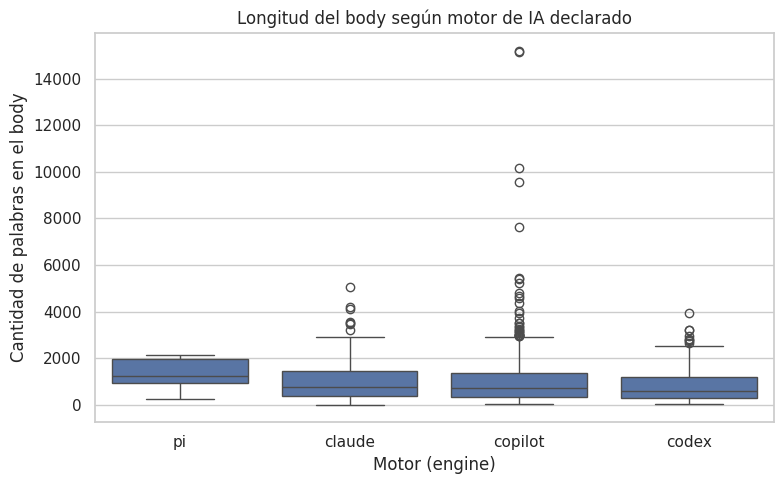

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
orden_engines = tabla_p1.sort_values("median", ascending=False).index
sns.boxplot(data=body_por_engine_top, x="engine", y="n_palabras_body", order=orden_engines, ax=ax)
ax.set_title("Longitud del body según motor de IA declarado")
ax.set_xlabel("Motor (engine)")
ax.set_ylabel("Cantidad de palabras en el body")
plt.tight_layout()
plt.show()

**Respuesta:** las medianas son relativamente parecidas entre los 4
motores principales (Claude 777, Copilot 725, Codex 587, Pi 1.243 con
muestra chica de solo 11 casos) -- no hay una diferencia drástica que
sugiera que un motor en particular requiera instrucciones sistemáticamente
más largas o cortas. Copilot muestra el máximo más alto (15.217 palabras,
el outlier de `dotnet/maui` visto en la sección 4), pero eso es un caso
puntual, no un patrón del motor en general. En conjunto, esto sugiere que
la longitud del body responde más a la complejidad de la tarea específica
del workflow que al motor de IA elegido para ejecutarla.


### Pregunta 2: ¿Los repositorios con múltiples archivos de workflow declaran un conjunto de herramientas (`tools`) más rico que los repositorios con un solo archivo?

*(combina `repositories`, `workflow_files` y `frontmatter_attributes`)*

En la sección 2 se vio que el 53% de los repositorios tiene un solo
archivo de workflow, mientras que unos pocos ("power users", como el
propio equipo de gh-aw) tienen decenas o cientos. Esta pregunta explora
si ese uso más intensivo también se refleja en workflows con más
herramientas (`tools.*`) declaradas por archivo.

**Variables:** cantidad de archivos por repositorio (de `workflow_files`,
agrupado por `repo_id`) vs cantidad de herramientas distintas declaradas
por archivo (de `frontmatter_attributes`, subclaves de `tools.*`).


In [17]:
archivos_por_repo = workflow_files.groupby("repo_id").size().rename("n_archivos_repo")
wf_con_conteo = workflow_files.merge(archivos_por_repo, on="repo_id")
wf_con_conteo["tipo_repo"] = wf_con_conteo["n_archivos_repo"].apply(
    lambda n: "repo con 1 solo archivo" if n == 1 else "repo con múltiples archivos"
)

tools_attrs = frontmatter_attributes[frontmatter_attributes["key_path"].str.startswith("tools.")]
n_tools_por_archivo = (
    tools_attrs.groupby("file_id")["key_path"]
    .apply(lambda ks: len(set(k.split(".")[1] for k in ks)))
    .rename("n_tools_distintas")
)

wf_con_tools = wf_con_conteo.merge(n_tools_por_archivo, on="file_id", how="left")
wf_con_tools["n_tools_distintas"] = wf_con_tools["n_tools_distintas"].fillna(0)

tabla_p2 = wf_con_tools.groupby("tipo_repo")["n_tools_distintas"].agg(["count", "mean", "median"]).round(2)
tabla_p2

,count,mean,median
tipo_repo,,,
repo con 1 solo archivo,183,2.95,2.0
repo con múltiples archivos,1226,3.84,2.0


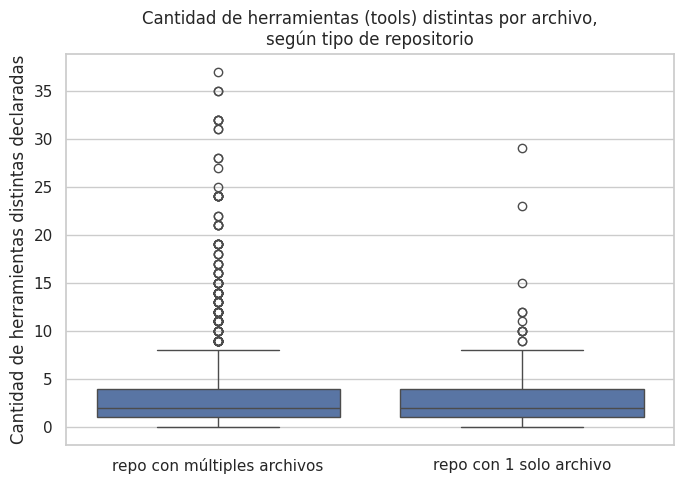

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=wf_con_tools, x="tipo_repo", y="n_tools_distintas", ax=ax)
ax.set_title("Cantidad de herramientas (tools) distintas por archivo,\nsegún tipo de repositorio")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de herramientas distintas declaradas")
plt.tight_layout()
plt.show()

**Respuesta:** la mediana es igual en ambos grupos (2 herramientas por
archivo), pero la **media** es más alta en repos con múltiples archivos
(3.84 vs 2.95) -- es decir, la diferencia no viene del workflow "típico"
sino de que los repos con muchos archivos tienen más casos extremos con
configuraciones de herramientas más ricas (coherente con que ahí están
los repos de referencia del propio equipo de gh-aw, que exploran más
combinaciones de herramientas a modo de ejemplo). En conjunto con la
Pregunta 1, esto refuerza la idea de que la *cantidad* de archivos por
repo dice más sobre el rol del repositorio (equipo de referencia vs
adoptante puntual) que sobre la complejidad típica de cada workflow
individual.


## 6. Hallazgos y limitaciones

### Hallazgos principales

**1. La mayoría de los repositorios adopta GH-AW para un caso de uso
puntual, no de forma intensiva.** El 53% de los 345 repositorios tiene
exactamente un archivo de workflow, y la distribución completa es
fuertemente asimétrica (mediana 1, media 4.1 archivos por repo) —
Sección 2. Los pocos repositorios con decenas o cientos de workflows
(`github/gh-aw` con 299, `github/gh-aw-firewall` con 70) son en su
mayoría repositorios del propio equipo que desarrolla la herramienta, no
adoptantes típicos.

**2. Los workflows de GH-AW siguen mayoritariamente el principio de
menor privilegio.** De los 1.237 archivos que declaran explícitamente
`permissions.contents`, el 99.8% pide únicamente permiso de lectura;
solo 2 archivos piden escritura sobre el contenido del repositorio —
Sección 3.3.

**3. GH-AW se usa más para tareas periódicas/bajo demanda que como bot
reactivo.** Los triggers `workflow_dispatch` (71.1%) y `schedule` (52.5%)
son ampliamente más frecuentes que triggers reactivos a eventos como
`issues` o `pull_request` — Sección 3.4.

**4. El motor de IA declarado no está asociado a una diferencia notable
en la longitud de las instrucciones del workflow.** Las medianas de
longitud del body son similares entre Claude (777), Copilot (725) y
Codex (587 palabras) — Sección 5, Pregunta 1 — lo que sugiere que la
complejidad de la tarea, no el motor elegido, es lo que determina qué
tan extensas son las instrucciones.

**5. El "rol" del repositorio (adoptante puntual vs repositorio de
referencia) se refleja más en la variedad de herramientas declaradas que
en el archivo típico.** La mediana de herramientas (`tools.*`) distintas
por archivo es igual (2) entre repos de 1 archivo y repos con varios,
pero la media es mayor en estos últimos (3.84 vs 2.95) — Sección 5,
Pregunta 2 — indicando que son unos pocos workflows más ricos en
herramientas, no la mayoría, los que elevan el promedio.

### Limitaciones

- **Cobertura parcial y snapshot temporal.** El dataset cubre 345
  repositorios confirmados como usuarios de GH-AW al 2026-09-05, de un
  conjunto más amplio de candidatos escaneados por Miner en el que ~1.450
  repos quedaron sin resolver (errores de red/repos eliminados, no
  analizados) durante la identificación inicial. Los workflows también
  pueden cambiar o eliminarse después de esta fecha; los hallazgos
  reflejan un momento puntual, no un estado permanente.
- **Sesgo hacia repositorios de referencia.** Como se vio en el Hallazgo
  1, unos pocos repos (en particular del propio equipo de gh-aw)
  concentran una fracción grande de los archivos analizados. Las
  estadísticas a nivel de *archivo* (no de *repositorio*) están
  parcialmente sobre-representadas por estos repos, que probablemente no
  son representativos de un uso "típico" de la herramienta.
- **Campos de frontmatter ausentes no son errores.** Muchos campos
  (`engine`, `network`, `strict`, etc.) los declara solo una fracción de
  los archivos (Sección 3.1); esto es un uso opcional legítimo, no un
  problema de calidad, pero limita cuánto se puede generalizar sobre
  esos campos a partir solo de los archivos que sí los declaran.
- **Un archivo con frontmatter no recuperable.** 1 de 1.409 archivos
  (0.07%) tiene el bloque de frontmatter mal formado en el repositorio de
  origen (sin delimitador de cierre), documentado y tratado en el
  Notebook 1. Se conservó en `workflow_files` pero no aporta a ningún
  análisis de `frontmatter_attributes`, y su longitud de body está
  inflada artificialmente (incluye contenido que originalmente era
  frontmatter) — no debe tratarse como un valor típico en comparaciones
  de longitud.
